In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

# **Predicting Whether the Customer Of A Financial Institution Will Exit Or Stay: Customer Churn Prediction**

# Importing Modules

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

# Loading Datasets

In [4]:
train_df = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv")
test_df = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv")

# Exploratory Data Analysis (EDA)

In [5]:
print(train_df.shape)
print(train_df.info)
print(train_df.columns.tolist())
print(train_df.nunique())
print(train_df.describe())
print(train_df.isnull().sum())

(90000, 14)
<bound method DataFrame.info of           id  customer_id  last_name  credit_score  country  gender   age  \
0          0     15788291    Iredale         559.0   France    Male  28.0   
1          1     15642816        Hs?         694.0   France  Female  37.0   
2          2     15632272      T'ien         585.0      NaN  Female  45.0   
3          3     15685826  Hightower         589.0    Spain    Male  25.0   
4          4     15658032    Hopkins         701.0   France    Male  39.0   
...      ...          ...        ...           ...      ...     ...   ...   
89995  89995     15609187        Cox         455.0   France  Female  36.0   
89996  89996     15801462   Yermakov         678.0  Germany    Male  31.0   
89997  89997     15584766     Knight         530.0   France    Male  31.0   
89998  89998     15671409      Scott         743.0  Germany  Female  28.0   
89999  89999     15759567       Shih         681.0    Spain    Male  37.0   

       tenure  acc_balance  pro

# Datatypes Of Training And Test Data

In [6]:
print("---Datatypes of Training Set---")
print(train_df.dtypes)
print("---Datatypes of Test Set---")
print(test_df.dtypes)

---Datatypes of Training Set---
id                    int64
customer_id           int64
last_name            object
credit_score        float64
country              object
gender               object
age                 float64
tenure                int64
acc_balance         float64
prod_count          float64
has_card            float64
is_active           float64
estimated_salary    float64
exit_status           int64
dtype: object
---Datatypes of Test Set---
id                    int64
customer_id           int64
last_name            object
credit_score        float64
country              object
gender               object
age                 float64
tenure                int64
acc_balance         float64
prod_count          float64
has_card            float64
is_active           float64
estimated_salary    float64
dtype: object


# Descriptive Statistics Of Training And Test Data

In [7]:
print("---Descriptive Statistics of Training Set---")
print(train_df.describe().T)
print("---Descriptive Statistics of Test Set---")
print(test_df.describe())

---Descriptive Statistics of Training Set---
                    count          mean           std          min  \
id                90000.0  4.499950e+04  25980.906451         0.00   
customer_id       90000.0  1.569209e+07  71297.959941  15565701.00   
credit_score      80444.0  6.564971e+02     80.016856       350.00   
age               90000.0  3.811953e+01      8.855203        18.00   
tenure            90000.0  5.017022e+00      2.804813         0.00   
acc_balance       82743.0  5.545673e+04  62788.474236         0.00   
prod_count        85137.0  1.552932e+00      0.548011         1.00   
has_card          90000.0  7.542889e-01      0.430510         0.00   
is_active         90000.0  4.971778e-01      0.499995         0.00   
estimated_salary  90000.0  1.123947e+05  50360.440702        11.58   
exit_status       90000.0  2.116000e-01      0.408445         0.00   

                          25%          50%           75%          max  
id                   22499.75     44999.50

# Identifying Missing Values

In [8]:
print("---Missing Values of Training Set---")
print(train_df.isnull().sum())
print("---Missing Values of Test Set---")
print(test_df.isnull().sum())

---Missing Values of Training Set---
id                     0
customer_id            0
last_name              0
credit_score        9556
country             6021
gender                 0
age                    0
tenure                 0
acc_balance         7257
prod_count          4863
has_card               0
is_active              0
estimated_salary       0
exit_status            0
dtype: int64
---Missing Values of Test Set---
id                     0
customer_id            0
last_name              0
credit_score        3185
country             4606
gender                 0
age                    0
tenure                 0
acc_balance         5251
prod_count          1717
has_card               0
is_active              0
estimated_salary       0
dtype: int64


# Imputing Numerical Variables With Mean

In [9]:
numerical = ['credit_score', 'acc_balance', 'prod_count']
n_imputer = SimpleImputer(strategy='mean')
train_df[numerical] = n_imputer.fit_transform(train_df[numerical])
test_df[numerical] = n_imputer.transform(test_df[numerical])

# Imputing Categorical Variables With Mode

In [10]:
categorical = ['country']
c_imputer = SimpleImputer(strategy = 'most_frequent')
train_df[categorical] = c_imputer.fit_transform(train_df[categorical])
test_df[categorical] = c_imputer.transform(test_df[categorical])                        

# Identifying Duplicates

In [11]:
print("---Duplicate Values of Training Set---")
print(train_df.duplicated().sum())
print("---Duplicate Values of Test Set---")
print(test_df.duplicated().sum())

---Duplicate Values of Training Set---
0
---Duplicate Values of Test Set---
0


# Dropping 'customer_id' Column 

In [12]:
correlation = train_df['exit_status'].corr(train_df['customer_id'])
print("Correlation between exit_status and customer_id:", correlation)

Correlation between exit_status and customer_id: -0.01565807903985813


Dropping customer Id since it has no correlation with the target variable

In [13]:
train_df = train_df.drop(["customer_id"], axis=1)
test_df = test_df.drop(['customer_id'], axis=1)

# Check for Outliers

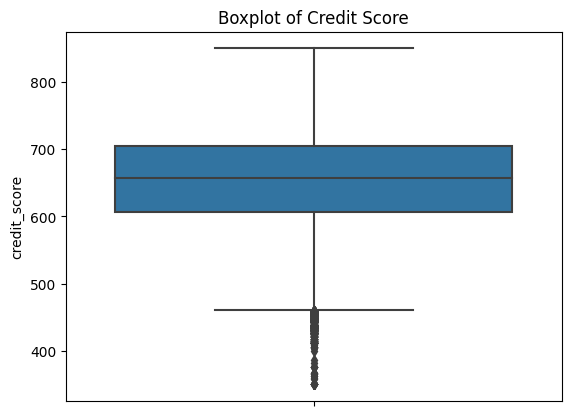

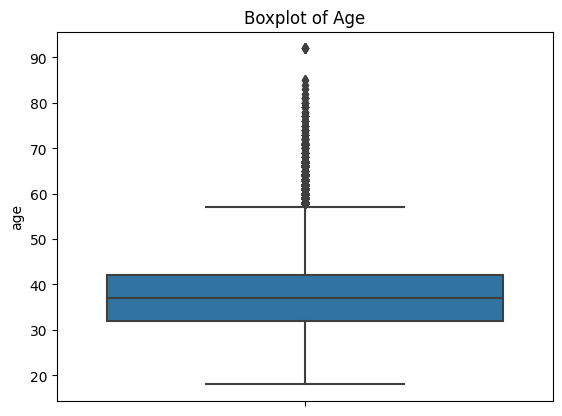

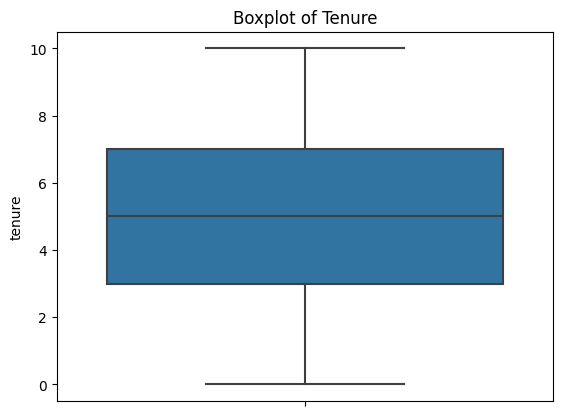

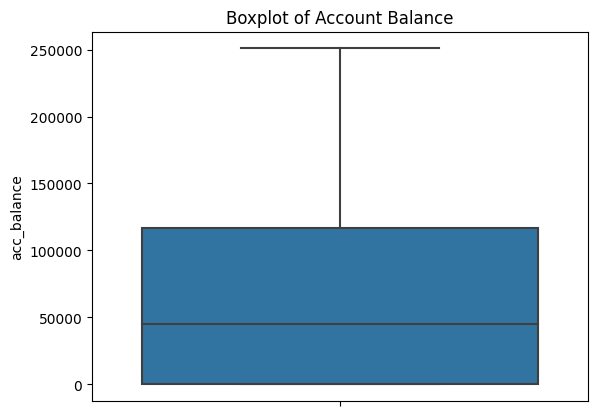

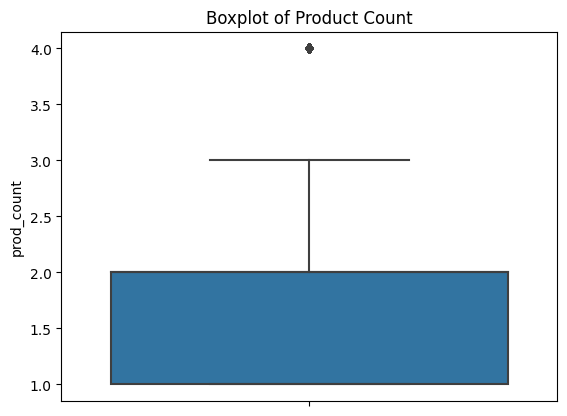

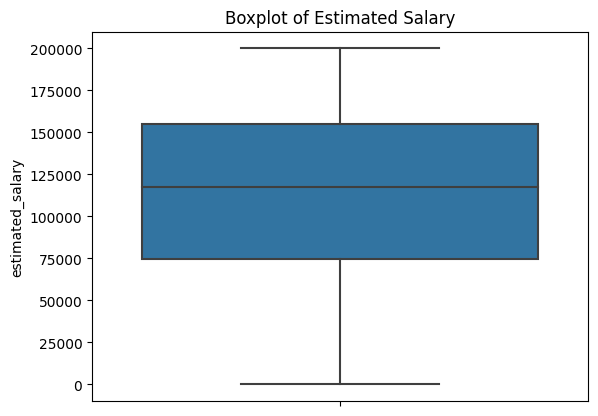

In [14]:
sns.boxplot(y=train_df['credit_score'])
plt.title("Boxplot of Credit Score")
plt.show()

sns.boxplot(y=train_df['age'])
plt.title("Boxplot of Age")
plt.show()

sns.boxplot(y=train_df['tenure'])
plt.title("Boxplot of Tenure")
plt.show()

sns.boxplot(y=train_df['acc_balance'])
plt.title("Boxplot of Account Balance")
plt.show()

sns.boxplot(y=train_df['prod_count'])
plt.title("Boxplot of Product Count")
plt.show()

sns.boxplot(y=train_df['estimated_salary'])
plt.title("Boxplot of Estimated Salary")
plt.show()

In this context, we choose not to drop outliers in features like Age, Product Count, and Credit Score. These outliers may reflect genuine customer behaviors such as older clients nearing retirement, highly engaged users with multiple products, or customers with exceptionally high or low credit scores. Such cases can be crucial for understanding patterns. Removing them could lead to biased results and reduce the model’s ability to generalize. Instead, we opt for appropriate handling techniques like scaling or transformation to retain valuable information.


# Visualisations

<Axes: xlabel='gender', ylabel='count'>

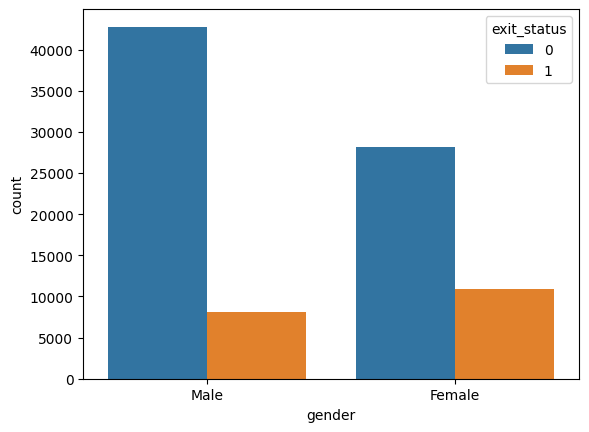

In [15]:
#Visualisation 1:
sns.countplot(data=train_df, x='gender', hue='exit_status')

The bar plot shows that while more male customers stayed overall, a higher proportion of female customers exited. This indicates that female customers may be more likely to leave the financial institution compared to males, making gender a potentially important factor in predicting customer churn.

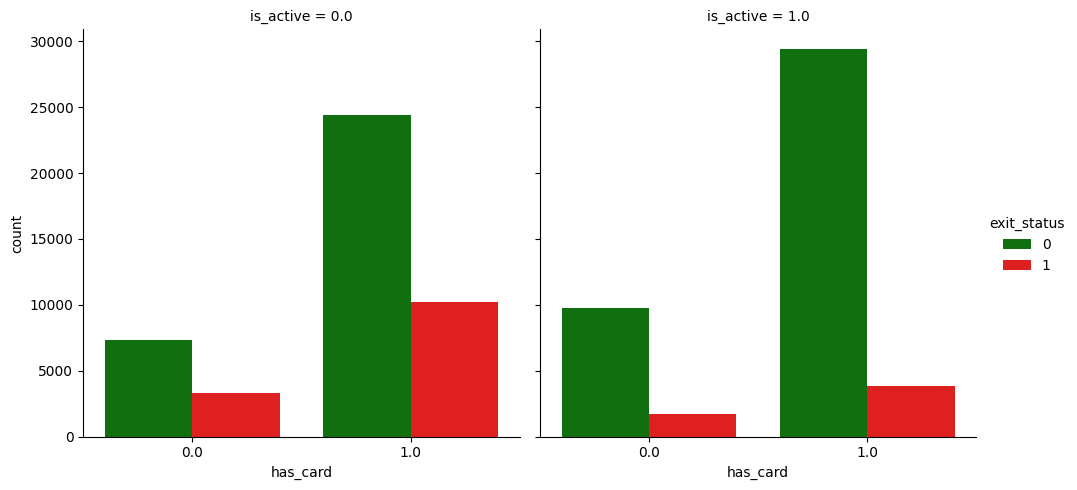

In [16]:
#Visualisation 2:
sns.catplot(data=train_df, x='has_card', hue='exit_status', col='is_active', kind='count', palette={0: 'green', 1: 'red'})
plt.show()

The plot shows the relationship between having a card, activity status, and customer exit. Among both active and inactive customers, those who have a card are more likely to stay. However, inactive customers show a higher churn rate overall. Notably, active customers with a card have the lowest exit rate, suggesting that both engagement and card ownership contribute to customer retention.

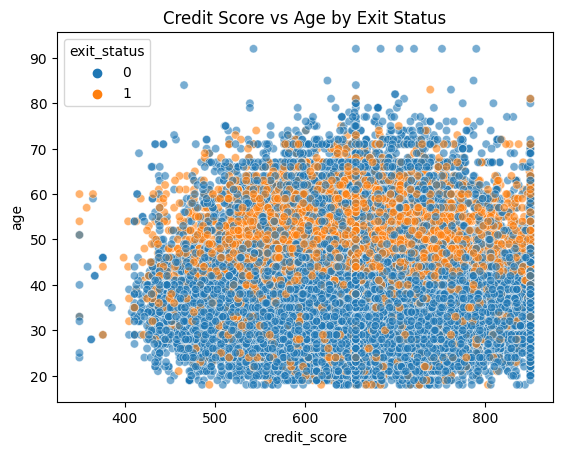

In [17]:
#Visualisation 3: 
sns.scatterplot(data=train_df, x='credit_score', y='age', hue='exit_status', alpha=0.6)
plt.title('Credit Score vs Age by Exit Status')
plt.show()

The scatter plot shows the relationship between credit score and age, with points colored by exit status. While most customers fall between credit scores of 500–750 and ages of 30–60, there is no sharp visual separation between those who stayed and exited. However, customers who exited (orange points) appear to be slightly more concentrated in the mid-age and mid-credit score range, suggesting these groups may be more likely to churn.

# Scaling Numerical Features And Encoding Categorical Features

In [18]:
#Scaling 
num_cols = ['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'has_card', 'is_active', 'estimated_salary']
scaler = MinMaxScaler()
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

#Encoding
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_df[['last_name']] = oe.fit_transform(train_df[['last_name']])
test_df[['last_name']] = oe.transform(test_df[['last_name']])

cat_cols = ['country', 'gender']
ohe = OneHotEncoder(sparse = False)
train_ohe = pd.DataFrame(ohe.fit_transform(train_df[cat_cols]), columns = ohe.get_feature_names_out(cat_cols), index = train_df.index)
test_ohe = pd.DataFrame(ohe.transform(test_df[cat_cols]), columns = ohe.get_feature_names_out(cat_cols), index = test_df.index)
train_df = train_df.drop(columns=cat_cols).join(train_ohe)
test_df = test_df.drop(columns=cat_cols).join(test_ohe)

MinMax scaling is applied to numerical features such as credit_score, age, tenure, acc_balance, prod_count, has_card, is_active, and estimated_salary. This technique transforms the features by scaling them to a fixed range, typically [0,1]. Scaling is important for models sensitive to feature magnitudes, such as logistic regression, KNN, and SVM, ensuring that all features contribute equally.

Ordinal encoding is used for the last_name column, which contains high-cardinality categorical data. Converting these values to numerical codes avoids creating a large number of features, which could increase complexity and lead to overfitting. Since the values do not have an inherent order, the encoding is applied purely for dimensionality reduction and efficient model processing.



One-hot encoding is applied to the country and gender columns, which have low cardinality. This method creates binary columns for each category, allowing models to treat each class as a distinct and unrelated entity. It prevents the model from assuming any ordinal relationship between categories and ensures accurate handling of nominal variables.

# Train - Validation Split

In [19]:
X = train_df.drop(columns=['exit_status'])
y = train_df['exit_status']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state=42)

# 1. Logistic Regression

In [20]:
results=[]
logreg = LogisticRegression(max_iter=1000)
#Fitting the model
logreg.fit(X_train, y_train)
#Predicting on validation set
y_pred_logreg = logreg.predict(X_val)
#Evaluating
acc_score_logreg = accuracy_score(y_val, y_pred_logreg)
conf_matrix_logreg = confusion_matrix(y_val, y_pred_logreg)
class_rep_logreg = classification_report(y_val, y_pred_logreg)
print("Accuracy:", acc_score_logreg)
print("Confusion Matrix:\n", conf_matrix_logreg)
print("Classification Report:\n", class_rep_logreg)
#Predicting on test data
test_preds_logreg = logreg.predict(test_df)
results.append(['Logistic Regression', acc_score_logreg])

Accuracy: 0.7893888888888889
Confusion Matrix:
 [[14209     0]
 [ 3791     0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      1.00      0.88     14209
           1       0.00      0.00      0.00      3791

    accuracy                           0.79     18000
   macro avg       0.39      0.50      0.44     18000
weighted avg       0.62      0.79      0.70     18000



# 2. K-Neighbours Classifier

In [21]:
knn = KNeighborsClassifier(n_neighbors=5) 
#Fitting the model
knn.fit(X_train, y_train)
#Predicting on validation set
y_pred_knn = knn.predict(X_val)
#Evaluating
acc_score_knn = accuracy_score(y_val, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_val, y_pred_knn)
class_rep_knn = classification_report(y_val, y_pred_knn)
print("KNN Accuracy:", acc_score_knn)
print("KNN Confusion Matrix:\n", conf_matrix_knn)
print("KNN Classification Report:\n", class_rep_knn)
#Predicting on test data
test_preds_knn = knn.predict(test_df)
results.append(['K-Nearest Neighbors', acc_score_knn])

KNN Accuracy: 0.7486666666666667
KNN Confusion Matrix:
 [[13211   998]
 [ 3526   265]]
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.93      0.85     14209
           1       0.21      0.07      0.10      3791

    accuracy                           0.75     18000
   macro avg       0.50      0.50      0.48     18000
weighted avg       0.67      0.75      0.70     18000



# 3. Decision Tree Classifier

In [22]:
dt = DecisionTreeClassifier(random_state=42)  
#Fitting the model
dt.fit(X_train, y_train)
#Predicting on validation set
y_pred_dt = dt.predict(X_val)
#Evaluating
acc_score_dt = accuracy_score(y_val, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_val, y_pred_dt)
class_rep_dt = classification_report(y_val, y_pred_dt)
print("Decision Tree Accuracy:", acc_score_dt)
print("Decision Tree Confusion Matrix:\n", conf_matrix_dt)
print("Decision Tree Classification Report:\n", class_rep_dt)
#Predicting on test data
test_preds_dt = dt.predict(test_df)
results.append(['Decision Tree', acc_score_dt])

Decision Tree Accuracy: 0.7937777777777778
Decision Tree Confusion Matrix:
 [[12326  1883]
 [ 1829  1962]]
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87     14209
           1       0.51      0.52      0.51      3791

    accuracy                           0.79     18000
   macro avg       0.69      0.69      0.69     18000
weighted avg       0.79      0.79      0.79     18000



# 4. XGBoost Classifier

In [23]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42) 
#Fitting the model
xgb.fit(X_train, y_train)
#Predicting on validation set
y_pred_xgb = xgb.predict(X_val)
#Evaluating
acc_score_xgb = accuracy_score(y_val, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_val, y_pred_xgb)
class_rep_xgb = classification_report(y_val, y_pred_xgb)
print("XGBoost Accuracy:", acc_score_xgb)
print("XGBoost Confusion Matrix:\n", conf_matrix_xgb)
print("XGBoost Classification Report:\n", class_rep_xgb)
#Predicting on test data
test_preds_xgb = xgb.predict(test_df)
results.append(['XGBoost', acc_score_xgb])

XGBoost Accuracy: 0.8608333333333333
XGBoost Confusion Matrix:
 [[13443   766]
 [ 1739  2052]]
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.91     14209
           1       0.73      0.54      0.62      3791

    accuracy                           0.86     18000
   macro avg       0.81      0.74      0.77     18000
weighted avg       0.85      0.86      0.85     18000



# 5. LightGBM Classifier

In [24]:
lgbm = LGBMClassifier(random_state=42)
#Fitting the model
lgbm.fit(X_train, y_train)
#Predicting on validation set
y_pred_lgbm = lgbm.predict(X_val)
#Evaluating
acc_score_lgbm = accuracy_score(y_val, y_pred_lgbm)
conf_matrix_lgbm = confusion_matrix(y_val, y_pred_lgbm)
class_rep_lgbm = classification_report(y_val, y_pred_lgbm)
print("LightGBM Accuracy:", acc_score_lgbm)
print("LightGBM Confusion Matrix:\n", conf_matrix_lgbm)
print("LightGBM Classification Report:\n", class_rep_lgbm)
#Predicting on test data
test_preds_lgbm = lgbm.predict(test_df)
results.append(['LightGBM', acc_score_lgbm])

[LightGBM] [Info] Number of positive: 15253, number of negative: 56747
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1368
[LightGBM] [Info] Number of data points in the train set: 72000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.211847 -> initscore=-1.313827
[LightGBM] [Info] Start training from score -1.313827
LightGBM Accuracy: 0.8631111111111112
LightGBM Confusion Matrix:
 [[13495   714]
 [ 1750  2041]]
LightGBM Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92     14209
           1       0.74      0.54      0.62      3791

    accuracy                           0.86     18000
   macro avg       0.81      0.74      0.77     18000
weighted avg       0.85      0.86      0

# 6. Random Forest Classifier

In [25]:
rf = RandomForestClassifier(random_state=42)
#Fitting the model
rf.fit(X_train, y_train)
#Predicting on validation set
y_pred_rf = rf.predict(X_val)
#Evaluating
acc_score_rf = accuracy_score(y_val, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_val, y_pred_rf)
class_rep_rf = classification_report(y_val, y_pred_rf)
print("Random Forest Accuracy:", acc_score_rf)
print("Random Forest Confusion Matrix:\n", conf_matrix_rf)
print("Random Forest Classification Report:\n", class_rep_rf)
#Predicting on test data
test_preds_rf = rf.predict(test_df)
results.append(['Random Forest', acc_score_rf])

Random Forest Accuracy: 0.8573333333333333
Random Forest Confusion Matrix:
 [[13556   653]
 [ 1915  1876]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     14209
           1       0.74      0.49      0.59      3791

    accuracy                           0.86     18000
   macro avg       0.81      0.72      0.75     18000
weighted avg       0.85      0.86      0.85     18000



# 7. Naive Bayes Model

In [26]:
nb = GaussianNB()
#Fitting the model
nb.fit(X_train, y_train)
#Predicting on validation set
y_pred_nb = nb.predict(X_val)
#Evaluating
acc_score_nb = accuracy_score(y_val, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_val, y_pred_nb)
class_rep_nb = classification_report(y_val, y_pred_nb)
print("Naive Bayes Accuracy:", acc_score_nb)
print("Naive Bayes Confusion Matrix:\n", conf_matrix_nb)
print("Naive Bayes Classification Report:\n", class_rep_nb)
#Predicting on test set
test_preds_nb = nb.predict(test_df)
results.append(['Naive Bayes', acc_score_nb])

Naive Bayes Accuracy: 0.7893888888888889
Naive Bayes Confusion Matrix:
 [[14209     0]
 [ 3791     0]]
Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.79      1.00      0.88     14209
           1       0.00      0.00      0.00      3791

    accuracy                           0.79     18000
   macro avg       0.39      0.50      0.44     18000
weighted avg       0.62      0.79      0.70     18000



# Hyperparameter Tuning

# 1. LightGBM Classifier (tuned)

In [27]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, -1],
    'num_leaves': [31, 50]
}

lgbm_tuned = LGBMClassifier(random_state=42, verbose=-1)
grid_search = GridSearchCV(
    estimator=lgbm_tuned,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
#Fitting the model
grid_search.fit(X_train, y_train)
lgbm = grid_search.best_estimator_
#Predicting on validation set
y_pred_lgbm_tuned = lgbm.predict(X_val)
#Evaluating
acc_score_lgbm_tuned = accuracy_score(y_val, y_pred_lgbm_tuned)
conf_matrix_lgbm_tuned = confusion_matrix(y_val, y_pred_lgbm_tuned)
class_rep_lgbm_tuned = classification_report(y_val, y_pred_lgbm_tuned)
print("LightGBM Best Parameters:", grid_search.best_params_)
print("LightGBM Accuracy:", acc_score_lgbm_tuned)
print("LightGBM Confusion Matrix:\n", conf_matrix_lgbm_tuned)
print("LightGBM Classification Report:\n", class_rep_lgbm_tuned)
#Predicting on test data
test_preds_lgbm_tuned = lgbm.predict(test_df)
results.append(['LightGBM (tuned)', acc_score_lgbm_tuned])

LightGBM Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
LightGBM Accuracy: 0.8637222222222222
LightGBM Confusion Matrix:
 [[13512   697]
 [ 1756  2035]]
LightGBM Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92     14209
           1       0.74      0.54      0.62      3791

    accuracy                           0.86     18000
   macro avg       0.81      0.74      0.77     18000
weighted avg       0.86      0.86      0.86     18000



# Random Forest Classifier (tuned)

In [28]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_tuned = RandomForestClassifier(random_state=42)
# GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
#Fitting on training data
grid_search_rf.fit(X_train, y_train)
rf_best = grid_search_rf.best_estimator_
#Predicting on validation set
y_pred_rf_tuned = rf_best.predict(X_val)
#Evaluating
acc_score_rf_tuned = accuracy_score(y_val, y_pred_rf_tuned)
conf_matrix_rf_tuned = confusion_matrix(y_val, y_pred_rf_tuned)
class_rep_rf_tuned = classification_report(y_val, y_pred_rf_tuned)
print("Random Forest Best Parameters:", grid_search_rf.best_params_)
print("Random Forest Accuracy :", acc_score_rf_tuned)
print("Random Forest Confusion Matrix:\n", conf_matrix_rf_tuned)
print("Random Forest Classification Report:\n", class_rep_rf_tuned)
#Predicting on test data
test_preds_rf = rf_best.predict(test_df)
results.append(['Random Forest (tuned)', acc_score_rf_tuned])

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Random Forest Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Accuracy : 0.8581111111111112
Random Forest Confusion Matrix:
 [[13680   529]
 [ 2025  1766]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91     14209
           1       0.77      0.47      0.58      3791

    accuracy                           0.86     18000
   macro avg       0.82      0.71      0.75     18000
weighted avg       0.85      0.86      0.84     18000



# XGboost Classifier (tuned)

In [29]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_tuned = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
#GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

#Fitting the model
grid_search_xgb.fit(X_train, y_train)
xgb = grid_search_xgb.best_estimator_
#Predicting on validation set
y_pred_xgb_tuned = xgb.predict(X_val)
#Evaluating
acc_score_xgb_tuned = accuracy_score(y_val, y_pred_xgb_tuned)
conf_matrix_xgb_tuned = confusion_matrix(y_val, y_pred_xgb_tuned)
class_rep_xgb_tuned = classification_report(y_val, y_pred_xgb_tuned)
print("XGBoost Best Parameters:", grid_search_xgb.best_params_)
print("XGBoost Accuracy:", acc_score_xgb_tuned)
print("XGBoost Confusion Matrix:\n", conf_matrix_xgb_tuned)
print("XGBoost Classification Report:\n", class_rep_xgb_tuned)
#Predicting on test data
test_preds_xgb_tuned = xgb.predict(test_df)
results.append(['XGBoost (tuned)', acc_score_xgb_tuned])

XGBoost Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
XGBoost Accuracy: 0.8625
XGBoost Confusion Matrix:
 [[13526   683]
 [ 1792  1999]]
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92     14209
           1       0.75      0.53      0.62      3791

    accuracy                           0.86     18000
   macro avg       0.81      0.74      0.77     18000
weighted avg       0.85      0.86      0.85     18000



# Comparison

In [30]:
results_df = pd.DataFrame(results, columns=['Model', 'R2'])
results_df = results_df.sort_values('R2', ascending = False).reset_index(drop = True)
print(results_df)

                   Model        R2
0       LightGBM (tuned)  0.863722
1               LightGBM  0.863111
2        XGBoost (tuned)  0.862500
3                XGBoost  0.860833
4  Random Forest (tuned)  0.858111
5          Random Forest  0.857333
6          Decision Tree  0.793778
7    Logistic Regression  0.789389
8            Naive Bayes  0.789389
9    K-Nearest Neighbors  0.748667


The model comparison based on R² scores shows that LightGBM (tuned) performed the best with a score of 0.8637, followed closely by its untuned version (0.8631). XGBoost and its tuned variant also showed strong performance, with scores above 0.860. Random Forest models performed slightly lower, around 0.858. Traditional models like Decision Tree, Logistic Regression, and Naive Bayes scored below 0.80, indicating comparatively weaker predictive power. K-Nearest Neighbors had the lowest performance at 0.7487. Overall, gradient boosting models outperformed others, even with minimal gains from tuning.

# Submission

In [31]:
sample_submission = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/sample_submission.csv")
sample_submission['exit_status'] = test_preds_lgbm
sample_submission.to_csv("submission.csv", index=False)